In [1]:
%load_ext autoreload
%autoreload
import dolfinx
import gmsh
import pyvista
import eitx
import scipy as sp
pyvista.set_jupyter_backend("static")


hwloc/linux: Ignoring PCI device with non-16bit domain.
Pass --enable-32bits-pci-domain to configure to support such devices
(warning: it would break the library ABI, don't enable unless really needed).
hwloc/linux: Ignoring PCI device with non-16bit domain.
Pass --enable-32bits-pci-domain to configure to support such devices
(warning: it would break the library ABI, don't enable unless really needed).


In [2]:
from PIL import Image

import matplotlib.pyplot as plt
import numpy as np
import scipy

print('Please, upload images of Phantoms')
# uploaded = files.upload()
#img = np.asarray(Image.open('fantom_1_2.jpg'))
# plt.imshow(img)

Please, upload images of Phantoms


In [3]:
DATAPATH = "../fin_data/datamat/"

## Teste de consitência da conversão

Fazendo o procedimento:
- Importando os dados de `datamat_1_0` do KIT4;
- Convertendo pro nosso formato usando o método `eitx.ConvertingData(method="KIT4")`;
- Fazendo a conversão inversa dos mesmos dados, do nosso formato pro KIT4, com o método `eitx.ConvertingData(method="adjacent")` que implementei agora.

(15, 16)


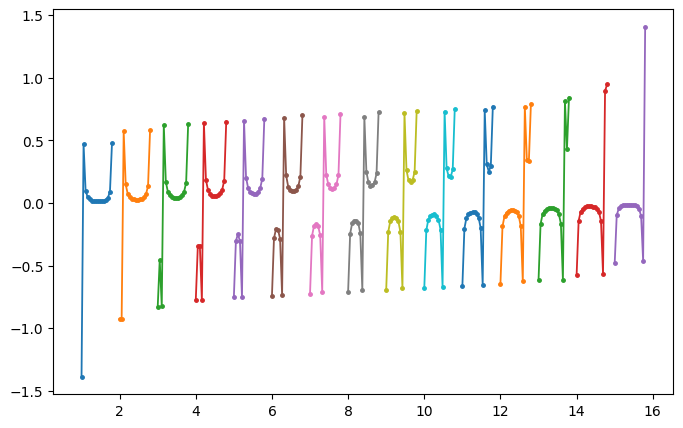

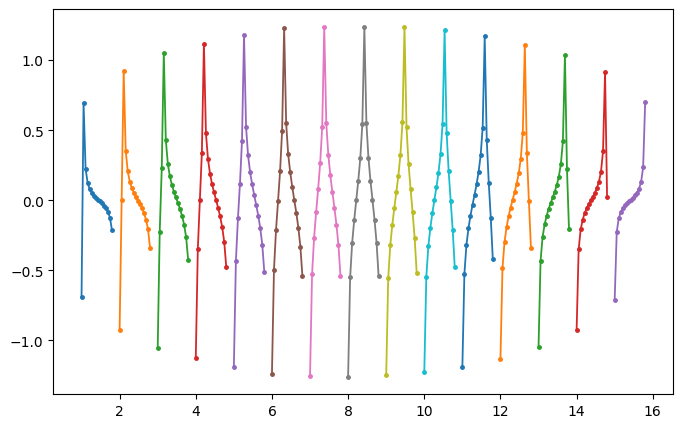

In [4]:
#Load data of background
mat = scipy.io.loadmat(DATAPATH+"datamat_1_0")
Uel=mat.get("Uel").T
CP=mat.get("CurrentPattern").T

#Selecting Potentials
Uel_b=Uel[-15:] #Matrix of measuarements
print(Uel_b.shape)

#Plot
fig, ax = plt.subplots(figsize=(8,5))
for i, U_vec in enumerate(Uel_b):
    x=np.linspace(1,1.8,16)+i
    ax.plot(x,U_vec, linewidth=1.3, marker='.', markersize=5);

#Selecting Potentials
list_U0_m=np.zeros_like(Uel_b)

#Converting data to our format
for index, potential in enumerate(Uel_b):
    list_U0_m[index]=eitx.ConvertingData(potential, method="KIT4")
list_U0=list_U0_m.flatten() #Matrix to vector

#Ploting converted data
fig, ax = plt.subplots(figsize=(8,5))
for i, U_vec in enumerate(list_U0_m):
    x=np.linspace(1,1.8,16)+i
    ax.plot(x,U_vec, linewidth=1.3, marker='.', markersize=5);


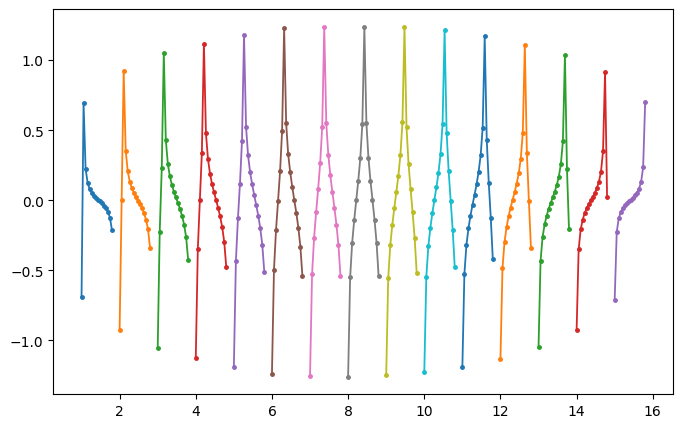

In [5]:
#Converting back to KIT4 format
converted_U0 = eitx.ConvertingData(list_U0_m,"adjacent")

# Plotting
fig, ax = plt.subplots(figsize=(8,5))
for i, U_vec in enumerate(converted_U0):
    x=np.linspace(1,1.8,16)+i
    ax.plot(x,U_vec, linewidth=1.3, marker='.', markersize=5)


In [6]:
#Checking difference
Uel_b - eitx.ConvertingData(list_U0_m,"adjacent")

array([[-6.96124462e-01, -2.24427352e-01, -1.26101922e-01,
        -7.98262319e-02, -5.23502119e-02, -3.30318419e-02,
        -1.78943719e-02, -3.91477187e-03,  8.18578813e-03,
         2.15820581e-02,  3.69124381e-02,  5.48143881e-02,
         8.10847181e-02,  1.23772918e-01,  2.14494828e-01,
         6.92824028e-01],
       [-1.55370812e-03, -9.25650658e-01, -3.54273658e-01,
        -2.06770608e-01, -1.34346548e-01, -8.81461981e-02,
        -5.38177681e-02, -2.43309881e-02,  1.09595188e-03,
         2.77187319e-02,  5.70470619e-02,  9.07693019e-02,
         1.37065222e-01,  2.07601542e-01,  3.42379992e-01,
         9.25212332e-01],
       [ 2.23452744e-01, -2.30671676e-01, -1.05338830e+00,
        -4.29089016e-01, -2.59849426e-01, -1.70260776e-01,
        -1.09593546e-01, -6.08126556e-02, -2.04369456e-02,
         2.00781844e-02,  6.28190844e-02,  1.10351984e-01,
         1.72927844e-01,  2.63364054e-01,  4.24917594e-01,
         1.05619084e+00],
       [ 3.48705438e-01,  9.36628125e

## Teste de geração de dados

- Gera algumas imagens de condutividade, com 1, 2 e 3 inclusões (2 amostras de cada);
- Plota cada imagem;
- Resolve o problema direto pra calcular os potenciais com a corrente $I$ fixada acima;
- Salva os dados de potenciais no nosso formato (aterrado), e no formato adjacente (do KIT4).

### Configurações

Error   : Gmsh has not been initialized


Info    : Meshing 1D...
Info    : Meshing curve 1 (Ellipse)
Info    : Done meshing 1D (Wall 0.0163687s, CPU 0.016899s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Delaunay)
Info    : Done meshing 2D (Wall 0.0656176s, CPU 0.065703s)
Info    : 2414 nodes 4027 elements


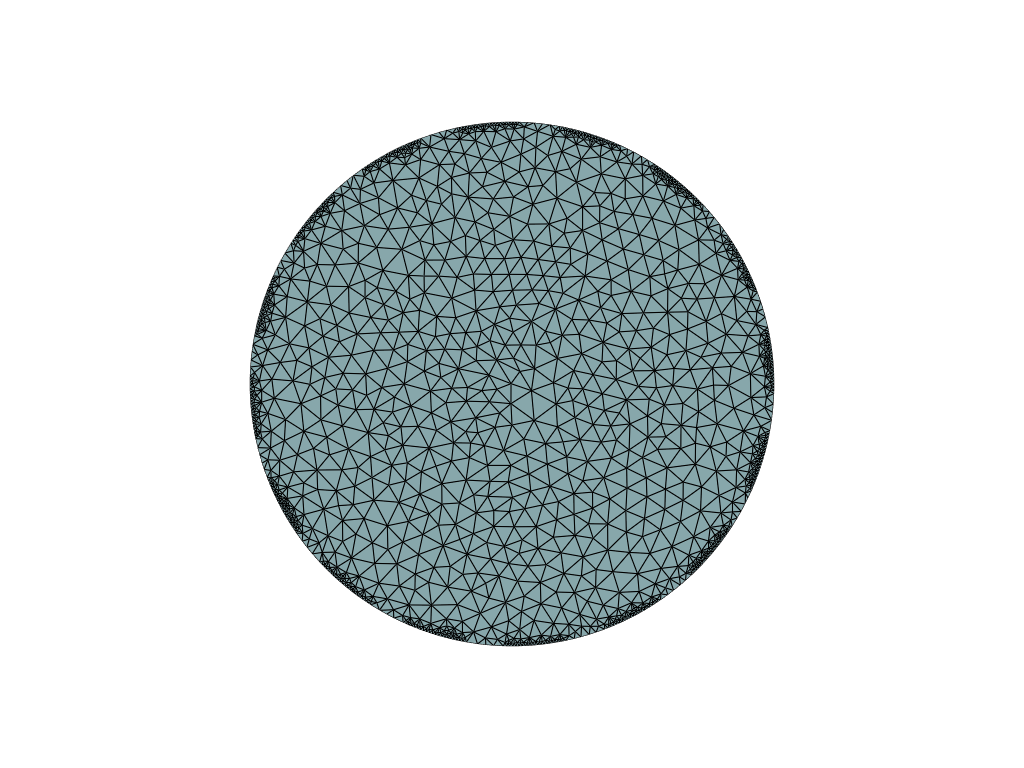

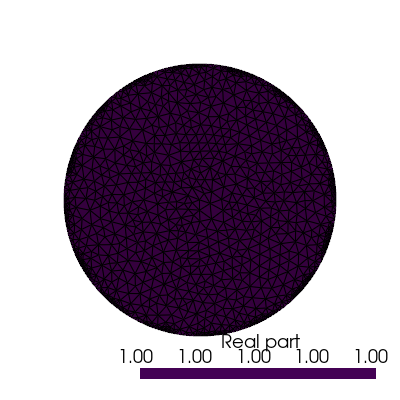

In [4]:
"Forward problem in background"
# Settings

#Loading data (somente para definir a corrente de maneira correta)
mat = sp.io.loadmat(DATAPATH+"datamat_1_0")
CP = mat.get("CurrentPattern").T

#Current
I_all=CP[0:16]/np.sqrt(2)
l, L=np.shape(I_all) #Number of experiments = 15, Number of Electrodes = 16
# print(I_all)# MESH (For real data)

"Basic Definitions"
radius=1               #Circle radius
per_cober=0.454728409  #Percentage of area covered by electrodes
rotate=0               #Electrodes Rotation
z=np.ones(L)*0.07858

'Return object with angular position of each electrode'
ele_pos = eitx.Electrodes(L, per_cober, rotate)
refine_n = 8     #Refinement mesh
n_in = 8         #Vertex on elec.
n_out = 2        #Vertex on gaps (Sometimes it is important.)

'Mesh'
# mesh_inverse=MyMesh(radius, refine_n, n_in, n_out, ele_pos)
mesh_object = eitx.MeshClass(ele_pos,0.4,0.4)
mesh = mesh_object.mesh


## Direct problem
dir_problem = eitx.DirectProblem(mesh_object,z)
V0 = dir_problem.V0   # Discontinuous Garlekin space function
V = dir_problem.V     # Continuous Garlekin space function

# 'Plot'
eitx.plot_mesh(mesh)

#"Define gamma as constant = Background"
iv, bg= 10, 1
gamma0 = dolfinx.fem.Function(V0)
gamma0.x.array[:] = bg

# "Plot"
eitx.plot_indicator_function(gamma0)

#Solving Forward Problem
list_u, list_U0_m = dir_problem.solve_problem_current(I_all, gamma0)
list_U0 = np.array(list_U0_m).flatten()

'Plot'
#np.set_printoptions(linewidth=750, precision=3, suppress=False, threshold=1000, formatter=None)
#print(np.matrix(np.round(list_U0_m, 3)))
'Retangular Mesh'

N = 128                               # grid with N*N points (works well with 0 < N < 400)
h = 2*radius/(N-1)                    # step size
x = [radius - i*h for i in range(N)]  # x grid points
y = [-radius + i*h for i in range(N)] # y grid points

# MESH x and y
mesh_x = np.zeros((N,N))              # x-Data (input of CNN)
mesh_y = np.zeros((N,N))              # y-Data (input of CNN)
for i in range(N):
  for j in range(N):
    mesh_x[i][j] = x[i]
    mesh_y[i][j] = y[j]

T1 = []                               # To save data

### Gerando os dados

In [5]:
#Importando dados do Hauptman
mat1 = scipy.io.loadmat("KIT4_Dbar_recon(2)/KIT4_Dbar_recon/KIT4_measdata/dataMat_adj_1_1.mat")

Generating sample: 1


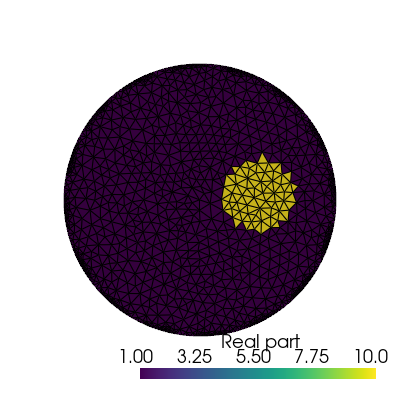

Generating sample: 2


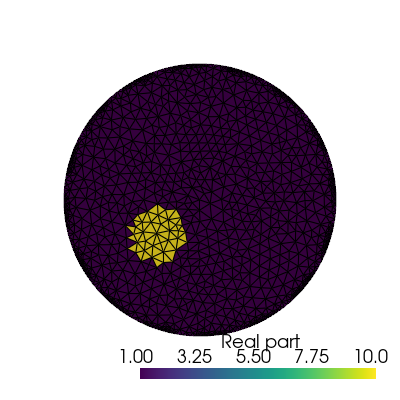

Generating sample: 3


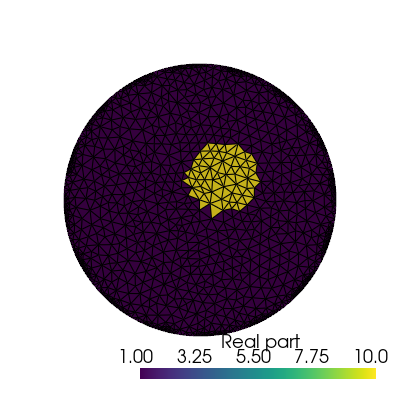

Generation of 1 circle(s) ended.
Generating sample: 4


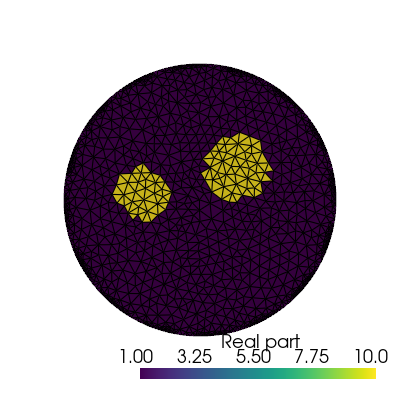

Generating sample: 5


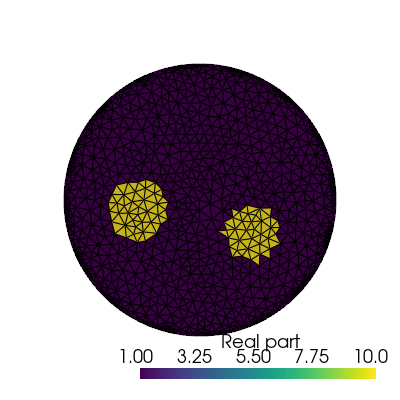

Generating sample: 6


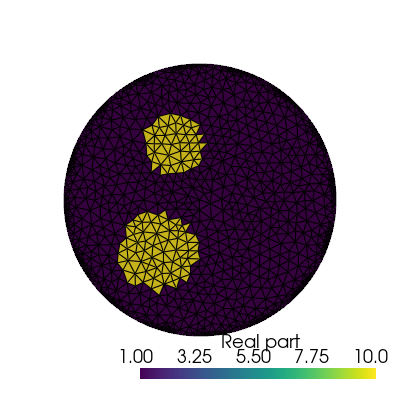

Generation of 2 circle(s) ended.
Generating sample: 7


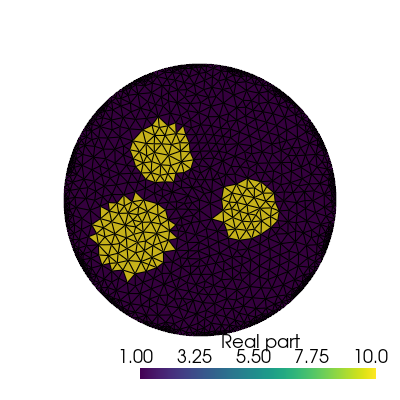

Generating sample: 8


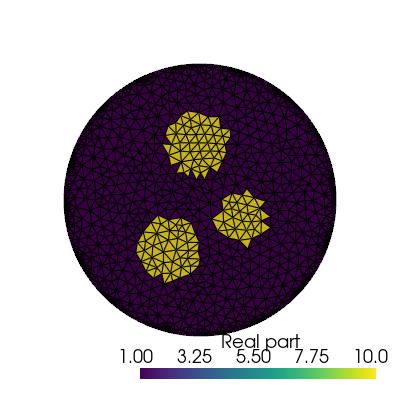

Generating sample: 9


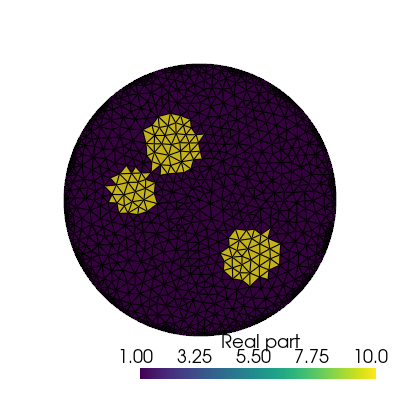

Generation of 3 circle(s) ended.


In [ ]:
import scipy.io


DBAR_PATH = "../dbar_data/"

# Loop for generating data

n_samples = [2000]               # number of samples in order: 1 circle, 2 circles, 3 circles, etc.
noise_level = 0.0                   # % of artificial noise in data

nn_samples = len(n_samples)
multi = 4                        # number of samples is multiplied by this number
for m in range(nn_samples):
  m_multi_m = (multi**m)*n_samples[m]
  rad_1 = np.random.uniform(0.15*radius, 0.3*radius, (m+1, m_multi_m))                # radius of the inclusions
  center_xy = np.random.uniform(-radius*0.5, radius*0.5, size=(2*(m+1), m_multi_m))   # xy-center of the inclusions
  # print(center_xy), print(rad_1), print(noise)
  vecpop = []                         # vector with indices to withdraw
  for p in range(m):
    for q in range(m - p):
      for j in range(m_multi_m):
        'withdraw indices when iclusions are overlapped'
        x0 = center_xy[2*p,j]
        y0 = center_xy[2*p+1,j]
        x1 = center_xy[2*(p+q)+2,j]
        y1 = center_xy[2*(p+q)+3,j]
        sumrad = rad_1[p,j] + rad_1[(p+q)+1,j]
        dist2 = (x0 - x1)**2 + (y0 - y1)**2
        if dist2 < sumrad**2 + 0.05*radius:               # if the circles touch each other
          vecpop.append(j)
  rad_1 = np.delete(rad_1,vecpop,1)     # remove the indices when the circles touch each other
  center_xy = np.delete(center_xy,vecpop,1)
  if rad_1.shape[1] < n_samples[m]:
    print('There are not enough samples. Correting the number of samples to: ' + str(rad_1.shape[1]))
    n_samples[m] = rad_1.shape[1]

  for sample in range(n_samples[m]):
    if m > 0:
      print('Generating sample: ' + str(np.sum(n_samples[:m]) + sample + 1))
    else:
      print('Generating sample: ' + str(sample + 1))

    "Generate Background + Inclusion"
    gamma = eitx.GammaCircle(V0,iv,bg,rad_1[0,sample],center_xy[0,sample], center_xy[1,sample]) 
    gamma_prov = gamma.x.array
    for p in range(m):
      ValuesCells1 = eitx.GammaCircle(V0,iv,0.0,rad_1[p+1,sample],center_xy[2*p+2,sample], center_xy[2*p+3,sample]).x.array
      gamma_prov = np.minimum(gamma_prov + ValuesCells1, iv)
    gamma.x.array[:]= gamma_prov

    #Plot and save fig
    eitx.plot_indicator_function(gamma,True,DBAR_PATH+f"solutions/sample_{m}_{sample}")
    np.save(DBAR_PATH+f"solutions/sample_{m}_{sample}.npy",gamma_prov)

    #Solve Forward Problem with Background + Inclusion
    list_u1, list_U1_m = dir_problem.solve_problem_current(I_all, gamma)

    # np.save(DBAR_PATH+f"ground_format_potential/sample_{m}_{sample}",list_U1_m)
    # np.save(DBAR_PATH+f"adjacent_format_potential/sample_{m}_{sample}",eitx.ConvertingData(list_U1_m,"adjacent"))
    scipy.io.savemat(DBAR_PATH+f"data_matrix/sample_{m}_{sample}.mat",{
      "U_ad0": np.array(list_U1_m).T,
      "U_ad10": np.array(list_U0_m).T,
      "MeasPat": mat1["MeasPat"]
    })

    scipy.io.savemat(DBAR_PATH+f"data_matrix_transpose/sample_{m}_{sample}.mat",{
      "U_ad0": np.array(list_U1_m).T,
      "U_ad10": np.array(list_U0_m).T,
      "MeasPat": mat1["MeasPat"]
    })
  
    "Define data in a homogeneus grid for training"
    T = np.zeros((l + 3,N,N))
    
    T[l] = mesh_x
    T[l+1] = mesh_y
    # T[l+2] = A
    T1.append(T)
  print('Generation of ' + str(m + 1) + ' circle(s) ended.')
# np.save('EIT_Data_for_CNN', T1)
# print('Data saved at file named: EIT_Data_for_CNN.')
# print(np.array(T1).shape)

In [1]:
import numpy as np
import scipy as sp

In [15]:
import os

adj_path = "dbar_data/adjacent_format_potential/"
grd_path = "dbar_data/ground_format_potential/"

adj_dir = os.listdir("dbar_data/adjacent_format_potential")
grd_dir = os.listdir("dbar_data/ground_format_potential")

Salvando arquivos .mat:

In [18]:
for file in adj_dir:
    sample = np.load(adj_path+file)
    print(sample)
    sp.io.savemat(adj_path+file+".mat",{"Uel":sample.T})

for file in grd_dir:
    sample = np.load(grd_path+file)
    print(sample)
    sp.io.savemat(grd_path+file+'.mat',{"Uel":sample.T})

[[-2.19553194  0.86519813  0.09976613  0.04409577  0.02746272  0.01899379
   0.01307966  0.008892    0.00722113  0.00853866  0.01113584  0.01334477
   0.02083839  0.04280986  0.09940326  0.91475185]
 [-1.33033382 -1.29243259  0.96792423  0.14356398  0.07292196  0.04623496
   0.0304872   0.01990685  0.01503835  0.01667823  0.02104416  0.02417971
   0.03515671  0.06808774  0.1442259   1.01731642]
 [-1.23056769 -0.42427449 -1.19100346  1.00958391  0.17522473  0.09154456
   0.05599316  0.03476183  0.02420539  0.02482529  0.03018483  0.03352076
   0.04611397  0.08546154  0.17133952  1.06308617]
 [-1.18647193 -0.32480627 -0.32498354 -1.18755831  1.09093877  0.19161846
   0.0989794   0.05706599  0.0361466   0.03356814  0.03894174  0.04190022
   0.05507989  0.09854197  0.19027778  1.09076111]
 [-1.15900921 -0.27934703 -0.22268077 -0.27184427 -1.1635774   1.1116815
   0.20015407  0.09839278  0.0550843   0.04458878  0.04823212  0.05003799
   0.06305717  0.10933579  0.2051261   1.11076806]
 [-1.1

## Comparações com kit4

In [15]:
def plotElectrodes(U_list):
    fig, ax = plt.subplots(figsize=(8,5))
    for i, U_vec in enumerate(U_list):
        x=np.linspace(1,1.8,16)+i
        ax.plot(x,U_vec, linewidth=1.3, marker='.', markersize=5)
    plt.show()

In [119]:
mat1 = scipy.io.loadmat("KIT4_Dbar_recon(2)/KIT4_Dbar_recon/KIT4_measdata/dataMat_adj_1_1.mat")
mat2 = scipy.io.loadmat(DATAPATH+"/datamat_1_1.mat")
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'CurrentPattern', 'MeasPattern', 'Uel'])

In [301]:
mat1.keys()

dict_keys(['__header__', '__version__', '__globals__', 'MeasPat', 'U_ad0', 'U_ad10'])

In [120]:
mat1["MeasPat"]

array([[ 1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,

In [5]:
mat1["U_ad10"].T-mat2['U_ad10'].T

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

In [6]:
len(list_U0_m)

NameError: name 'list_U0_m' is not defined

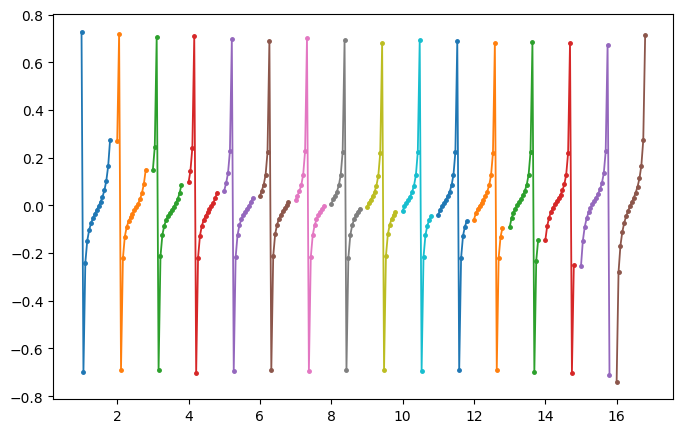

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
for i, U_vec in enumerate(mat1["U_ad0"].T):
    x=np.linspace(1,1.8,16)+i
    ax.plot(x,U_vec, linewidth=1.3, marker='.', markersize=5);

Info    : Meshing 1D...
Info    : Meshing curve 1 (Ellipse)
Info    : Done meshing 1D (Wall 0.0183013s, CPU 0.017412s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Delaunay)
Info    : Done meshing 2D (Wall 0.0751705s, CPU 0.074603s)
Info    : 2414 nodes 4027 elements


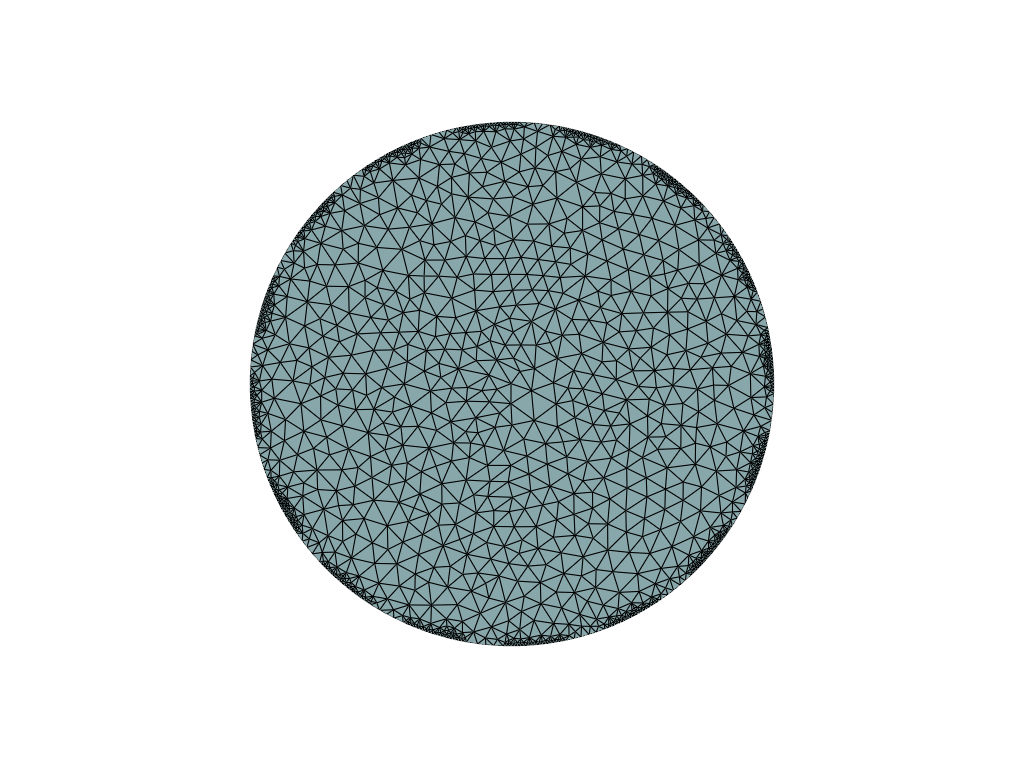

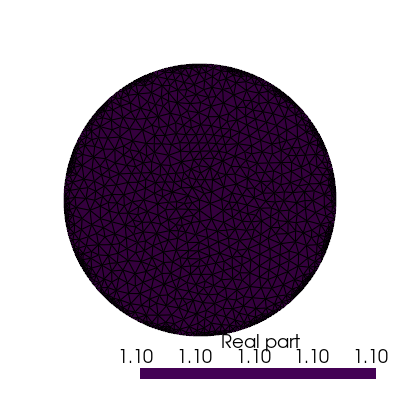

In [247]:
"Forward problem in background"
# Settings

#Loading data (somente para definir a corrente de maneira correta)
mat = sp.io.loadmat(DATAPATH+"datamat_1_2")
CP = mat.get("CurrentPattern").T

#Current
I_all=CP[:16]/np.sqrt(2)
# I_all=mat1["MeasPat"]
l, L=np.shape(I_all) #Number of experiments = 15, Number of Electrodes = 16
# print(I_all)# MESH (For real data)

"Basic Definitions"
radius=1               #Circle radius
per_cober=0.454728409  #Percentage of area covered by electrodes
rotate=0               #Electrodes Rotation
z=np.ones(L)*0.07858

'Return object with angular position of each electrode'
ele_pos = eitx.Electrodes(L, per_cober, rotate)
refine_n = 8     #Refinement mesh
n_in = 8         #Vertex on elec.
n_out = 2        #Vertex on gaps (Sometimes it is important.)

'Mesh'
# mesh_inverse=MyMesh(radius, refine_n, n_in, n_out, ele_pos)
mesh_object = eitx.MeshClass(ele_pos,0.4,0.4)
mesh = mesh_object.mesh


## Direct problem
dir_problem = eitx.DirectProblem(mesh_object,z)
V0 = dir_problem.V0   # Discontinuous Garlekin space function
V = dir_problem.V     # Continuous Garlekin space function

# 'Plot'
eitx.plot_mesh(mesh)

#"Define gamma as constant = Background"
iv, bg= 10, 1.1
gamma0 = dolfinx.fem.Function(V0)
gamma0.x.array[:] = bg

# "Plot"
eitx.plot_indicator_function(gamma0)

#Solving Forward Problem
list_u, list_U0_m = dir_problem.solve_problem_current(I_all, gamma0)
list_U0 = np.array(list_U0_m).flatten()

'Plot'
#np.set_printoptions(linewidth=750, precision=3, suppress=False, threshold=1000, formatter=None)
#print(np.matrix(np.round(list_U0_m, 3)))
'Retangular Mesh'

N = 128                               # grid with N*N points (works well with 0 < N < 400)
h = 2*radius/(N-1)                    # step size
x = [radius - i*h for i in range(N)]  # x grid points
y = [-radius + i*h for i in range(N)] # y grid points

# MESH x and y
mesh_x = np.zeros((N,N))              # x-Data (input of CNN)
mesh_y = np.zeros((N,N))              # y-Data (input of CNN)
for i in range(N):
  for j in range(N):
    mesh_x[i][j] = x[i]
    mesh_y[i][j] = y[j]

T1 = []                               # To save data

In [248]:
I_all

array([[1.00, -1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 1.00, -1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 1.00, -1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 1.00, -1.00, 0.00, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 1.00, -1.00, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 0.00, 1.00, -1.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00, -1.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00, -1.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00, -1.00,
        0.00, 0.00,

In [249]:
# array_U0_m = np.array(eitx.ConvertingData(list_U0_m,method="adjacent"))
array_U0_m = np.array(list_U0_m)

array_U0_m_converted = eitx.ConvertingData(list_U0_m,method="adjacent")

In [250]:
kit4_bg_U = np.array([
    eitx.ConvertingData(U,"KIT4") for U in mat["Uel"].T[0:16]
])

In [251]:
mat["MeasPattern"].T

array([[ 1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,

F(gamma_0)


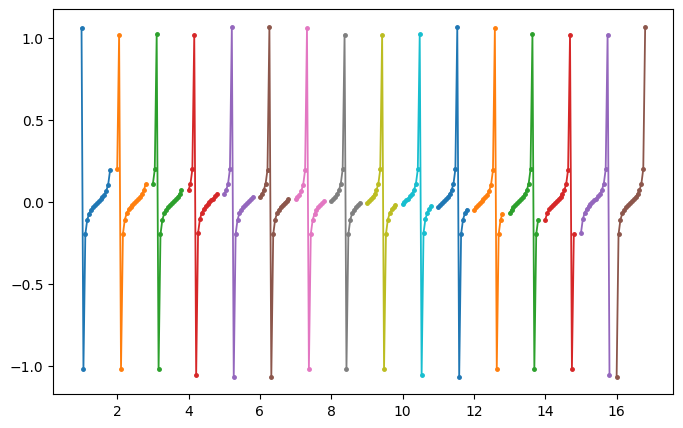

F(gamm0) convertido


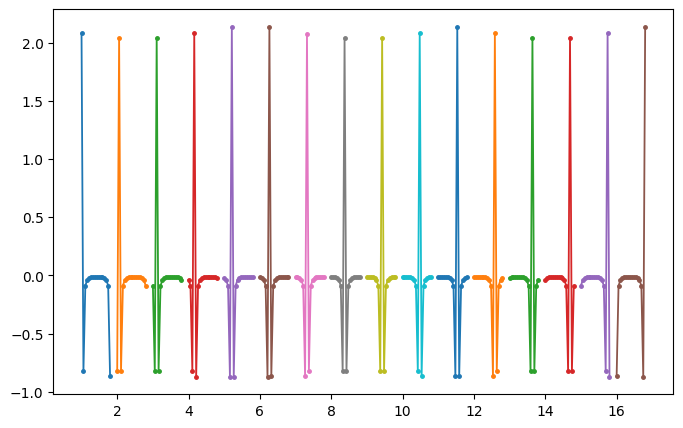

U_ad10


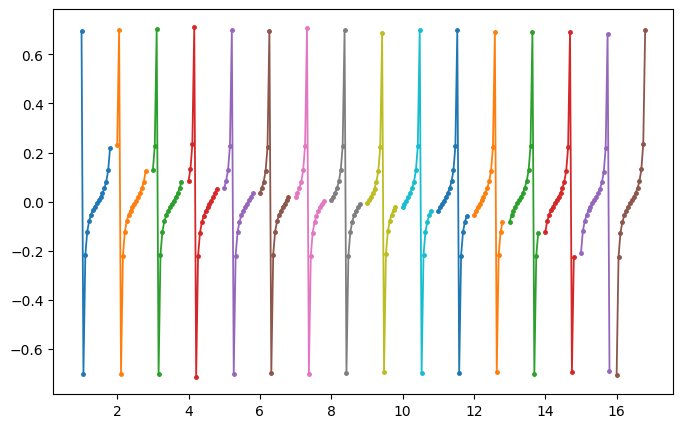

datamat_1_0


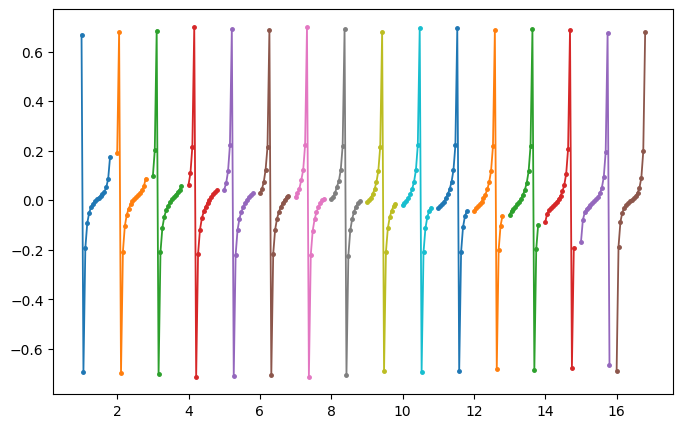

In [252]:
print("F(gamma_0)")
list_U0_mmat2 = scipy.io.loadmat(DATAPATH+"/datamat_1_2.mat")

fig, ax = plt.subplots(figsize=(8,5))
for i, U_vec in enumerate(list_U0_m):
    x=np.linspace(1,1.8,16)+i
    ax.plot(x,U_vec, linewidth=1.3, marker='.', markersize=5)
plt.show()
list_U0_m

print("F(gamm0) convertido")
fig, ax = plt.subplots(figsize=(8,5))
for i, U_vec in enumerate(array_U0_m_converted):
    x=np.linspace(1,1.8,16)+i
    ax.plot(x,U_vec, linewidth=1.3, marker='.', markersize=5)
plt.show()

print("U_ad10")
fig, ax = plt.subplots(figsize=(8,5))
for i, U_vec in enumerate(mat1["U_ad10"].T):
    x=np.linspace(1,1.8,16)+i
    ax.plot(x,U_vec, linewidth=1.3, marker='.', markersize=5)
plt.show()

print("datamat_1_0")
fig, ax = plt.subplots(figsize=(8,5))
for i, U_vec in enumerate(kit4_bg_U):
    x=np.linspace(1,1.8,16)+i
    ax.plot(x,U_vec, linewidth=1.3, marker='.', markersize=5)
plt.show()

### Comparando dados do KIT4 com Hauptmann

#### U_ad10

In [199]:
mat1 = scipy.io.loadmat("KIT4_Dbar_recon(2)/KIT4_Dbar_recon/KIT4_measdata/dataMat_adj_1_1.mat")
mat2 = scipy.io.loadmat(DATAPATH+"/datamat_1_0.mat")
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'CurrentPattern', 'MeasPattern', 'Uel'])

In [291]:
mat["MeasPattern"]

array([[ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1],
       [-1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, -1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, -1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, -1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, -1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, -1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, -1,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, -1,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, -1,  1,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  1,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  1,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,

Padrões

In [201]:
mat1["MeasPat"]

array([[ 1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,

Correntes do

In [202]:
mat2["CurrentPattern"].T[:16]

array([[1.41, -1.41, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 1.41, -1.41, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 1.41, -1.41, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 1.41, -1.41, 0.00, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 1.41, -1.41, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 0.00, 1.41, -1.41, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.41, -1.41, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.41, -1.41, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.41, -1.41,
        0.00, 0.00,

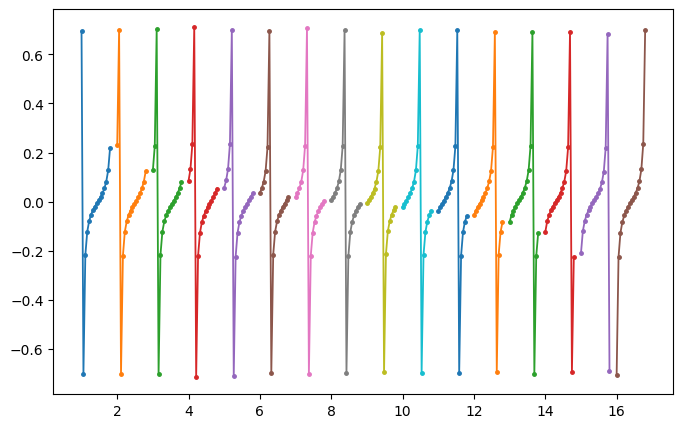

In [294]:
kit4_bg_U = np.array([
    eitx.ConvertingData(U,"KIT4") for U in mat2["Uel"].T[:16]
])
plotElectrodes(kit4_bg_U)

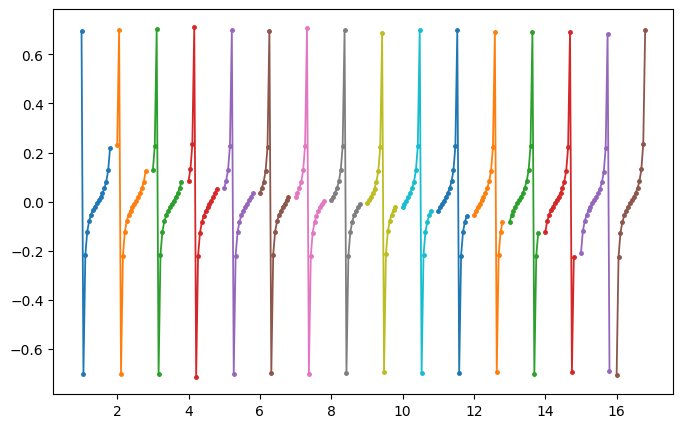

In [295]:
plotElectrodes(mat1["U_ad10"].T)

In [296]:
diff = kit4_bg_U-mat1["U_ad10"].T

In [297]:
np.linalg.norm(diff)

0.014772079909936505

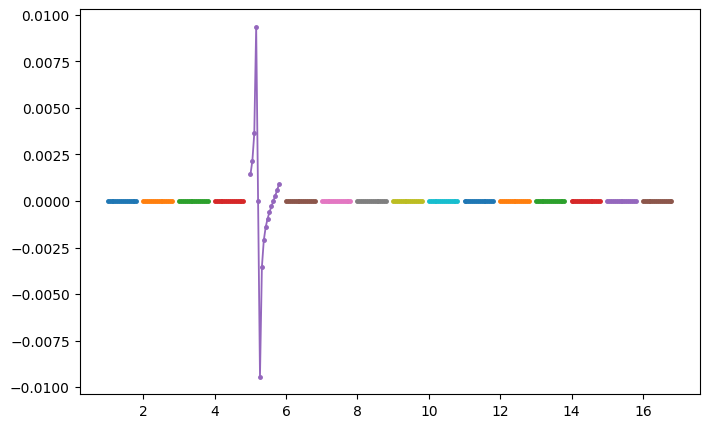

In [298]:
plotElectrodes(diff)

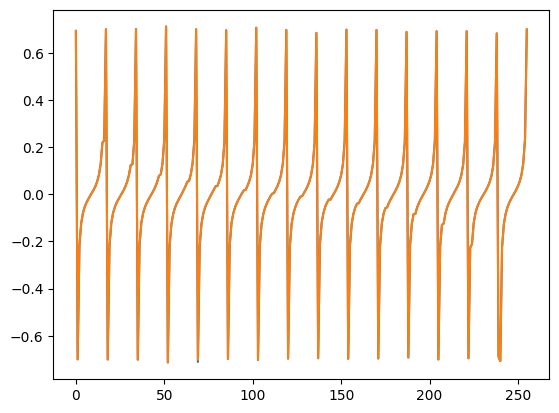

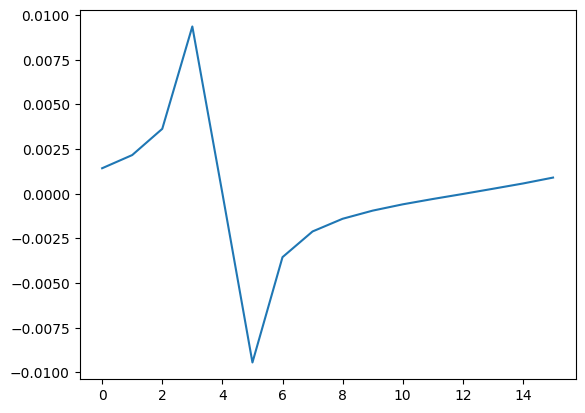

In [299]:
plt.plot(kit4_bg_U.ravel())
plt.plot(mat1["U_ad10"].T.ravel())
plt.show()

plt.plot(kit4_bg_U[4]-mat1["U_ad10"].T[4])
plt.show()

In [300]:
I_all

array([[1.00, -1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 1.00, -1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 1.00, -1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 1.00, -1.00, 0.00, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 1.00, -1.00, 0.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 0.00, 1.00, -1.00, 0.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00, -1.00, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00, -1.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00, -1.00,
        0.00, 0.00,

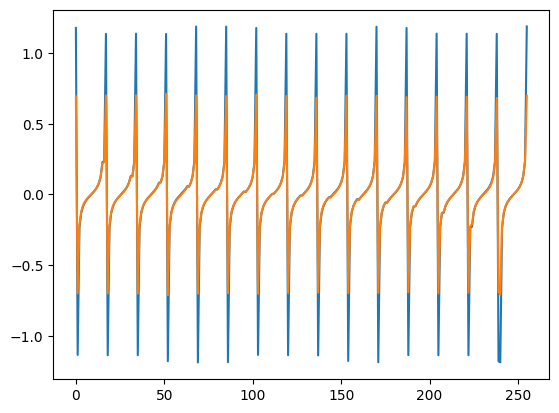

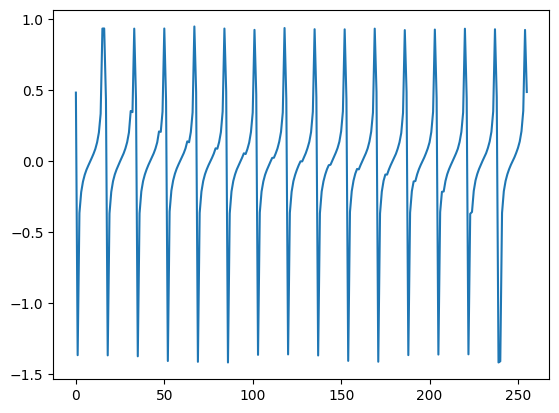

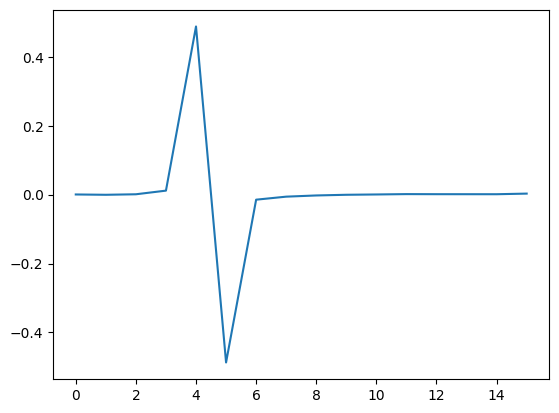

In [227]:
U0_array = np.array(list_U0_m)
plt.plot(U0_array.ravel())
plt.plot(mat1["U_ad10"].T.ravel())
plt.show()

plt.plot(U0_array.ravel()-mat1["U_ad10"].ravel())
plt.show()

plt.plot(U0_array[4]-mat1["U_ad10"].T[4])
plt.show()

#### U_ad0

In [37]:
mat1 = scipy.io.loadmat("KIT4_Dbar_recon(2)/KIT4_Dbar_recon/KIT4_measdata/dataMat_adj_1_2.mat")
mat2 = scipy.io.loadmat(DATAPATH+"/datamat_1_2.mat")
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'CurrentPattern', 'MeasPattern', 'Uel'])

In [38]:
mat["MeasPattern"]

array([[ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1],
       [-1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, -1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, -1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, -1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, -1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, -1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, -1,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, -1,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, -1,  1,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  1,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  1,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,

Padrões

In [39]:
mat1["MeasPat"]

array([[ 1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1, -1,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,

Correntes do

In [40]:
mat2["CurrentPattern"].T[:16]

array([[ 1.41421356, -1.41421356,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ],
       [ 0.        ,  1.41421356, -1.41421356,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ],
       [ 0.        ,  0.        ,  1.41421356, -1.41421356,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ],
       [ 0.        ,  0.        ,  0.        ,  1.41421356, -1.41421356,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ],
       [ 0.        ,  0.        ,  0

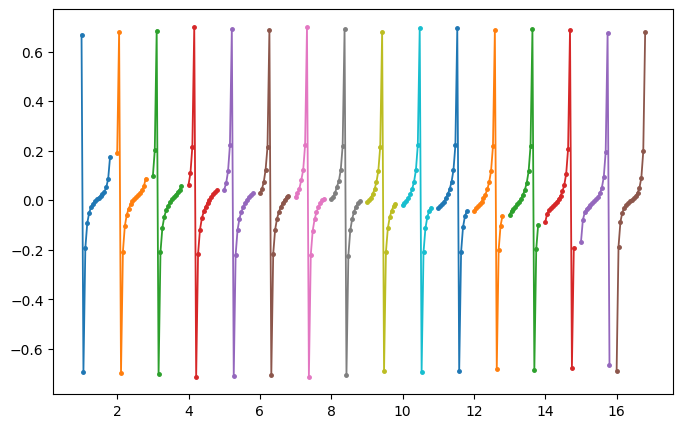

In [41]:
kit4_bg_U = np.array([
    eitx.ConvertingData(U,"KIT4") for U in mat2["Uel"].T[:16]
])
plotElectrodes(kit4_bg_U)

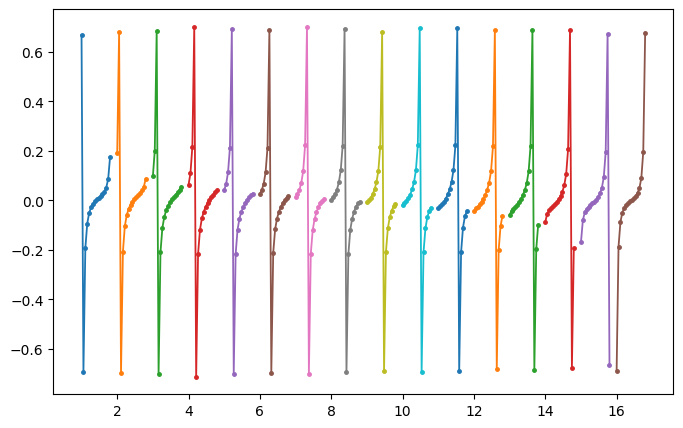

In [42]:
plotElectrodes(mat1["U_ad0"].T)

In [43]:
diff = kit4_bg_U-mat1["U_ad0"].T

In [44]:
np.linalg.norm(diff)

0.034199272168495186

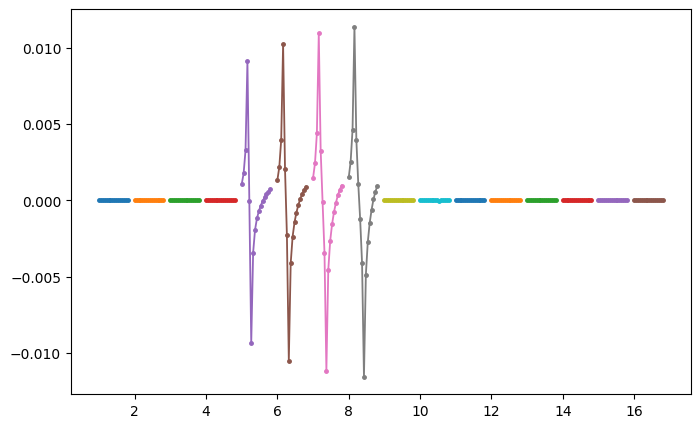

In [45]:
plotElectrodes(diff)

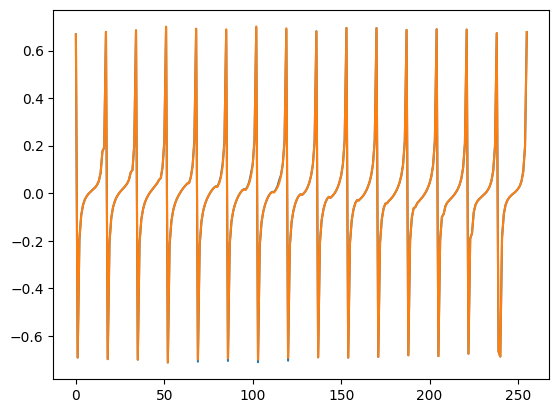

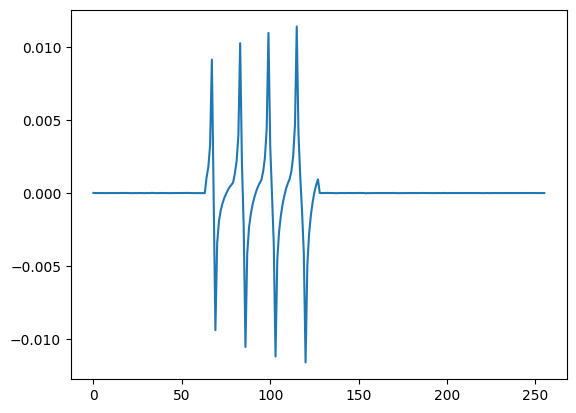

In [47]:
plt.plot(kit4_bg_U.ravel())
plt.plot(mat1["U_ad0"].T.ravel())
plt.show()

plt.plot(kit4_bg_U.ravel()-mat1["U_ad0"].T.ravel())
plt.show()

### Verificando dados do Hauptman


In [280]:
import os
HAUPTMAN_DATAPATH = "KIT4_Dbar_recon(2)/KIT4_Dbar_recon/KIT4_measdata/"

listdir = os.listdir(HAUPTMAN_DATAPATH)
listdir.sort()
listdir

mat1_uad10_list = []
for file in listdir:
    file_path = HAUPTMAN_DATAPATH+file
    mat_data = scipy.io.loadmat(file_path)
    mat1_uad10_list.append(mat_data["U_ad10"]) 

In [282]:
listdir

['dataMat_adj_1_1.mat',
 'dataMat_adj_1_2.mat',
 'dataMat_adj_1_3.mat',
 'dataMat_adj_1_4.mat',
 'dataMat_adj_2_1.mat',
 'dataMat_adj_2_2.mat',
 'dataMat_adj_2_3.mat',
 'dataMat_adj_2_4.mat',
 'dataMat_adj_2_5.mat',
 'dataMat_adj_2_6.mat',
 'dataMat_adj_3_1.mat',
 'dataMat_adj_3_2.mat',
 'dataMat_adj_3_3.mat',
 'dataMat_adj_3_4.mat',
 'dataMat_adj_3_5.mat',
 'dataMat_adj_3_6.mat',
 'dataMat_adj_4_1.mat',
 'dataMat_adj_4_2.mat',
 'dataMat_adj_4_3.mat',
 'dataMat_adj_4_4.mat',
 'dataMat_adj_5_1.mat',
 'dataMat_adj_5_2.mat',
 'dataMat_adj_6_1.mat',
 'dataMat_adj_6_2.mat',
 'dataMat_adj_6_3.mat',
 'dataMat_adj_6_4.mat',
 'dataMat_adj_6_5.mat',
 'dataMat_adj_6_6.mat',
 'dataMat_adj_6_7.mat',
 'dataMat_adj_7_1.mat',
 'dataMat_adj_7_2.mat',
 'dataMat_adj_8_1.mat',
 'dataMat_adj_8_2.mat',
 'dataMat_adj_8_3.mat',
 'dataMat_adj_8_4.mat',
 'dataMat_adj_8_5.mat',
 'dataMat_adj_8_6.mat']

In [281]:
for i in range(len(mat1_uad10_list)-1):
    # print(mat1_uad10_list[i+1]-mat1_uad10_list[i])
    print(np.linalg.norm(mat1_uad10_list[i+1]-mat1_uad10_list[i]))

0.0
0.0
0.0
0.02529690225093297
0.0
0.0
0.0
0.0
0.0
0.04879440268202913
0.0
0.0
0.0
0.0
0.0
0.023859599178875094
0.0
0.0
0.0
0.00318808065452078
0.0
0.007840580627120388
0.0
0.0
0.0
0.0
0.0
0.0
0.7655960285394267
0.0
0.021065516735319225
0.0
0.0
0.0
0.0
0.0
